# TASK 1: DATA MERGE FOR PRODUCT RECOMMENDATION
**Goal:** Merge customer_transactions and customer_social_profiles to predict product purchases

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import os

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print(" Libraries loaded")

 Libraries loaded


## 1. LOAD DATA

In [39]:
transactions_df = pd.read_csv('customer_transactions - customer_transactions.csv')
social_df = pd.read_csv('customer_social_profiles - customer_social_profiles.csv')

print(f"Transactions: {transactions_df.shape}")
print(f"Social: {social_df.shape}")
display(transactions_df.head())
display(social_df.head())

Transactions: (150, 6)
Social: (155, 5)


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


## 2. EXPLORATORY DATA ANALYSIS

In [40]:
print("=== SUMMARY STATISTICS ===")
print("\nTransactions:")
print(transactions_df.describe())
print("\nSocial:")
print(social_df.describe())
print("\n=== DATA TYPES ===")
print("\nTransactions:", transactions_df.dtypes.to_dict())
print("\nSocial:", social_df.dtypes.to_dict())

=== SUMMARY STATISTICS ===

Transactions:
       customer_id_legacy  transaction_id  purchase_amount  customer_rating
count          150.000000      150.000000       150.000000        140.00000
mean           148.760000     1075.500000       280.780000          2.98500
std             30.046425       43.445368       121.329595          1.20699
min            100.000000     1001.000000        51.000000          1.00000
25%            121.250000     1038.250000       179.000000          1.95000
50%            150.500000     1075.500000       274.000000          3.00000
75%            174.750000     1112.750000       388.500000          4.00000
max            199.000000     1150.000000       495.000000          5.00000

Social:
       engagement_score  purchase_interest_score
count        155.000000               155.000000
mean          75.606452                 3.152903
std           14.568021                 1.142867
min           50.000000                 1.000000
25%           63.500

In [41]:
print("=== DATA QUALITY ===")
print("\nTransactions - Missing:")
print(transactions_df.isnull().sum())
print(f"Duplicates: {transactions_df.duplicated().sum()}")
print("\nSocial - Missing:")
print(social_df.isnull().sum())
print(f"Duplicates: {social_df.duplicated().sum()}")

=== DATA QUALITY ===

Transactions - Missing:
customer_id_legacy     0
transaction_id         0
purchase_amount        0
purchase_date          0
product_category       0
customer_rating       10
dtype: int64
Duplicates: 0

Social - Missing:
customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
dtype: int64
Duplicates: 5


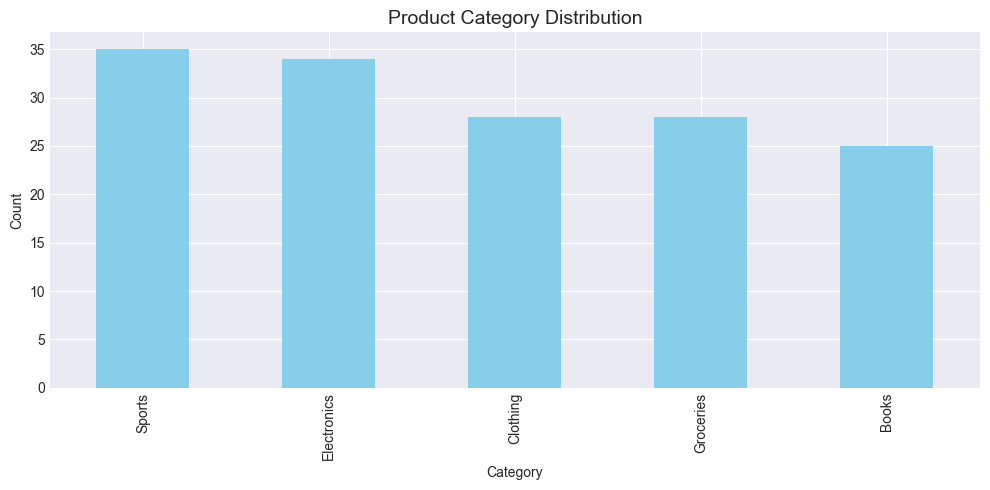

In [42]:
# PLOT 1: Product Category Distribution
fig, ax = plt.subplots(figsize=(10, 5))
transactions_df['product_category'].value_counts().plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Product Category Distribution', fontsize=14)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

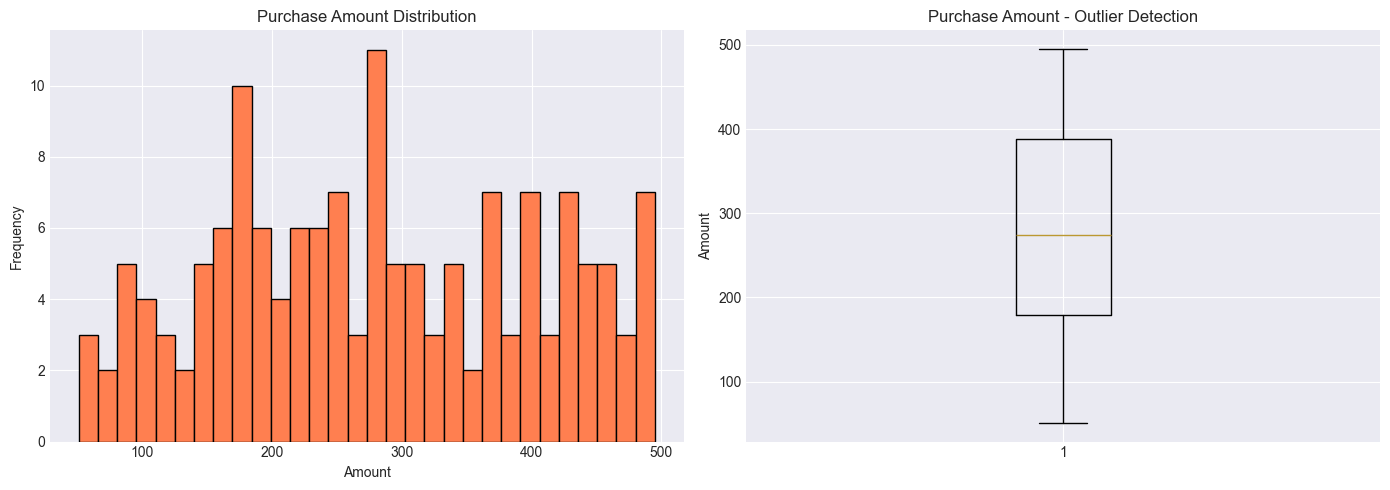

In [43]:
# PLOT 2: Purchase Amount Distribution with Outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(transactions_df['purchase_amount'], bins=30, color='coral', edgecolor='black')
axes[0].set_title('Purchase Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[1].boxplot(transactions_df['purchase_amount'])
axes[1].set_title('Purchase Amount - Outlier Detection')
axes[1].set_ylabel('Amount')
plt.tight_layout()
plt.show()

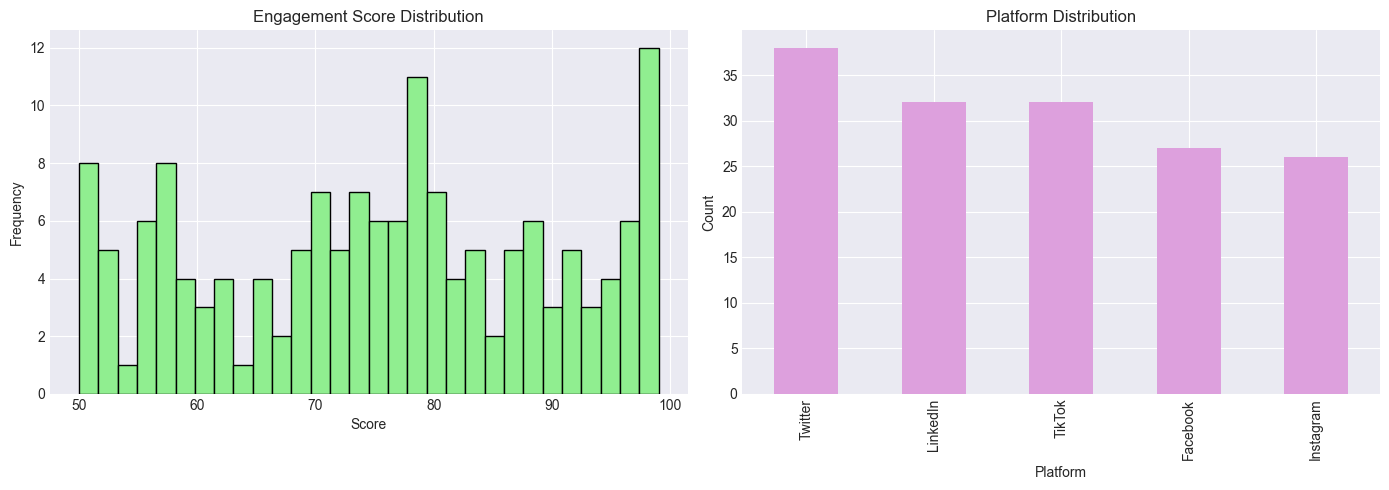

In [44]:
# PLOT 3: Social Media Engagement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(social_df['engagement_score'], bins=30, color='lightgreen', edgecolor='black')
axes[0].set_title('Engagement Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
social_df['social_media_platform'].value_counts().plot(kind='bar', ax=axes[1], color='plum')
axes[1].set_title('Platform Distribution')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

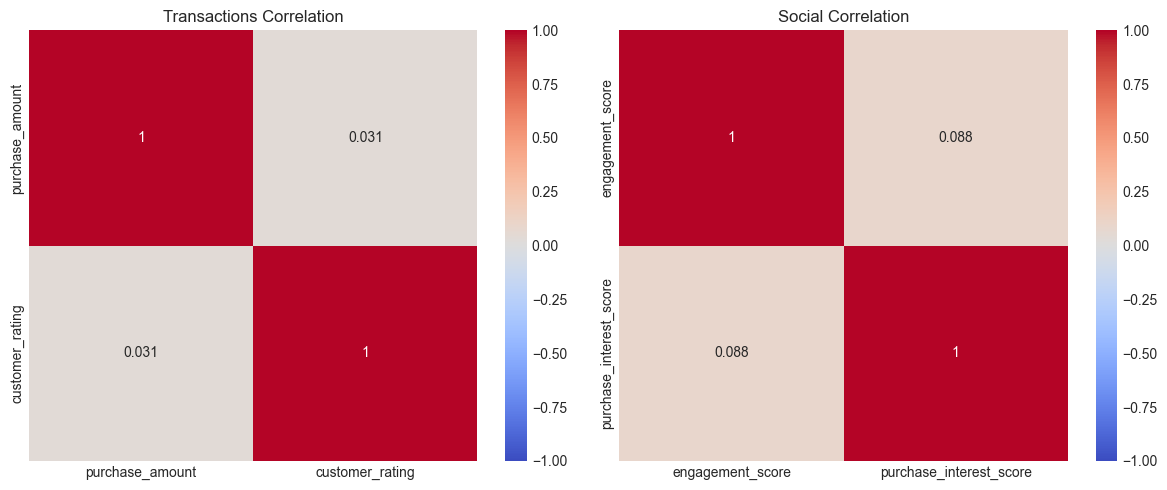

In [45]:
# PLOT 4: Correlation Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
trans_corr = transactions_df[['purchase_amount', 'customer_rating']].corr()
sns.heatmap(trans_corr, annot=True, cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Transactions Correlation')
social_corr = social_df[['engagement_score', 'purchase_interest_score']].corr()
sns.heatmap(social_corr, annot=True, cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Social Correlation')
plt.tight_layout()
plt.show()

## 3. DATA CLEANING

In [46]:
# Handle missing ratings
missing_before = transactions_df['customer_rating'].isnull().sum()
transactions_df['customer_rating'].fillna(transactions_df['customer_rating'].median(), inplace=True)
print(f"Missing ratings: {missing_before} → {transactions_df['customer_rating'].isnull().sum()}")

# Remove duplicates
transactions_df.drop_duplicates(inplace=True)
social_df.drop_duplicates(inplace=True)
print(f"Cleaned - Transactions: {transactions_df.shape}, Social: {social_df.shape}")

Missing ratings: 10 → 0
Cleaned - Transactions: (150, 6), Social: (150, 5)


## 4. ALIGN CUSTOMER IDs

In [47]:
# Remove 'A' prefix from social IDs to match transaction IDs
social_df['customer_id'] = social_df['customer_id_new'].str.replace('A', '').astype(int)
transactions_df['customer_id'] = transactions_df['customer_id_legacy']

print(f"Unique customers - Transactions: {transactions_df['customer_id'].nunique()}")
print(f"Unique customers - Social: {social_df['customer_id'].nunique()}")

Unique customers - Transactions: 75
Unique customers - Social: 84


## 5. FEATURE ENGINEERING

In [48]:
# Aggregate transaction features per customer
transaction_features = transactions_df.groupby('customer_id').agg({
    'purchase_amount': ['mean', 'sum', 'count'],
    'customer_rating': 'mean',
    'product_category': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

transaction_features.columns = ['customer_id', 'avg_purchase_amount', 'total_spent', 
                                 'transaction_count', 'avg_rating', 'most_purchased_category']

print("Transaction features:")
display(transaction_features.head())

Transaction features:


,customer_id,avg_purchase_amount,total_spent,transaction_count,avg_rating,most_purchased_category
0,100,279.500000,559,2,4.300000,Books
1,101,254.000000,1016,4,2.525000,Books
2,102,189.666667,569,3,3.433333,Electronics
3,103,265.666667,797,3,4.200000,Sports
4,104,349.000000,698,2,1.450000,Clothing


In [49]:
# Aggregate social features per customer
social_features = social_df.groupby('customer_id').agg({
    'engagement_score': 'mean',
    'purchase_interest_score': 'mean',
    'social_media_platform': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
    'review_sentiment': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

social_features.columns = ['customer_id', 'avg_engagement_score', 'avg_purchase_interest', 
                           'primary_platform', 'dominant_sentiment']

print("Social features:")
display(social_features.head())

Social features:


,customer_id,avg_engagement_score,avg_purchase_interest,primary_platform,dominant_sentiment
0,100,77.000000,4.400000,Instagram,Negative
1,101,68.000000,1.000000,Twitter,Neutral
2,102,51.000000,4.800000,LinkedIn,Neutral
3,103,64.333333,2.866667,Instagram,Positive
4,104,83.000000,2.933333,Twitter,Negative


## 6. MERGE DATASETS

In [50]:
# Inner join on customer_id (keeps only customers in both datasets)
merged_df = transaction_features.merge(social_features, on='customer_id', how='inner')

print(f"Merged: {merged_df.shape}")
display(merged_df.head())

Merged: (61, 10)


,customer_id,avg_purchase_amount,total_spent,transaction_count,avg_rating,most_purchased_category,avg_engagement_score,avg_purchase_interest,primary_platform,dominant_sentiment
0,100,279.500000,559,2,4.300000,Books,77.000000,4.400000,Instagram,Negative
1,101,254.000000,1016,4,2.525000,Books,68.000000,1.000000,Twitter,Neutral
2,102,189.666667,569,3,3.433333,Electronics,51.000000,4.800000,LinkedIn,Neutral
3,103,265.666667,797,3,4.200000,Sports,64.333333,2.866667,Instagram,Positive
4,104,349.000000,698,2,1.450000,Clothing,83.000000,2.933333,Twitter,Negative


## 7. MERGE VALIDATION

In [51]:
print("=== MERGE VALIDATION ===")
print(f"Before - Transactions: {len(transaction_features)}, Social: {len(social_features)}")
print(f"After - Merged: {len(merged_df)}")
print(f"\nMissing values:\n{merged_df.isnull().sum()}")
print(f"\nDuplicates: {merged_df.duplicated().sum()}")
print("\n Merge successful - all customers matched")

=== MERGE VALIDATION ===
Before - Transactions: 75, Social: 84
After - Merged: 61

Missing values:
customer_id                0
avg_purchase_amount        0
total_spent                0
transaction_count          0
avg_rating                 0
most_purchased_category    0
avg_engagement_score       0
avg_purchase_interest      0
primary_platform           0
dominant_sentiment         0
dtype: int64

Duplicates: 0

 Merge successful - all customers matched


## 8. ADDITIONAL FEATURES

In [53]:
# Create derived features
merged_df['engagement_x_interest'] = merged_df['avg_engagement_score'] * merged_df['avg_purchase_interest']
merged_df['spending_per_transaction'] = merged_df['total_spent'] / merged_df['transaction_count']
merged_df['sentiment_encoded'] = merged_df['dominant_sentiment'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})

# One-hot encode platform
platform_dummies = pd.get_dummies(merged_df['primary_platform'], prefix='platform')
merged_df = pd.concat([merged_df, platform_dummies], axis=1)

print(f" Final shape: {merged_df.shape}")
print(f"Features: {list(merged_df.columns)}")

 Final shape: (61, 23)
Features: ['customer_id', 'avg_purchase_amount', 'total_spent', 'transaction_count', 'avg_rating', 'most_purchased_category', 'avg_engagement_score', 'avg_purchase_interest', 'primary_platform', 'dominant_sentiment', 'engagement_x_interest', 'spending_per_transaction', 'sentiment_encoded', 'platform_Facebook', 'platform_Instagram', 'platform_LinkedIn', 'platform_TikTok', 'platform_Twitter', 'platform_Facebook', 'platform_Instagram', 'platform_LinkedIn', 'platform_TikTok', 'platform_Twitter']


## 9. FINAL SUMMARY

In [54]:
print("=== TASK 1 COMPLETE ===")
print(f"Customers: {len(merged_df)}")
print(f"Features: {merged_df.shape[1]}")
print(f"\nTarget (most_purchased_category):\n{merged_df['most_purchased_category'].value_counts()}")
print("\nNumerical summary:")
display(merged_df.describe())

=== TASK 1 COMPLETE ===
Customers: 61
Features: 23

Target (most_purchased_category):
most_purchased_category
Electronics    18
Books          14
Clothing       14
Sports          8
Groceries       7
Name: count, dtype: int64

Numerical summary:


,customer_id,avg_purchase_amount,total_spent,transaction_count,avg_rating,avg_engagement_score,avg_purchase_interest,engagement_x_interest,spending_per_transaction,sentiment_encoded
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,148.803279,281.552186,552.213115,1.918033,3.098525,74.225410,3.084973,232.164060,281.552186,0.032787
std,30.241153,94.570997,340.622377,0.971169,1.028367,13.139171,1.016477,92.433379,94.570997,0.855710
min,100.000000,64.000000,64.000000,1.000000,1.100000,50.000000,1.000000,66.300000,64.000000,-1.000000
25%,125.000000,216.500000,286.000000,1.000000,2.550000,66.500000,2.666667,180.000000,216.500000,-1.000000
50%,147.000000,279.500000,460.000000,2.000000,3.000000,75.000000,3.133333,238.950000,279.500000,0.000000
75%,179.000000,364.000000,764.000000,2.000000,3.860000,83.000000,3.825000,289.050000,364.000000,1.000000
max,199.000000,465.000000,1863.000000,5.000000,5.000000,99.000000,4.800000,417.600000,465.000000,1.000000


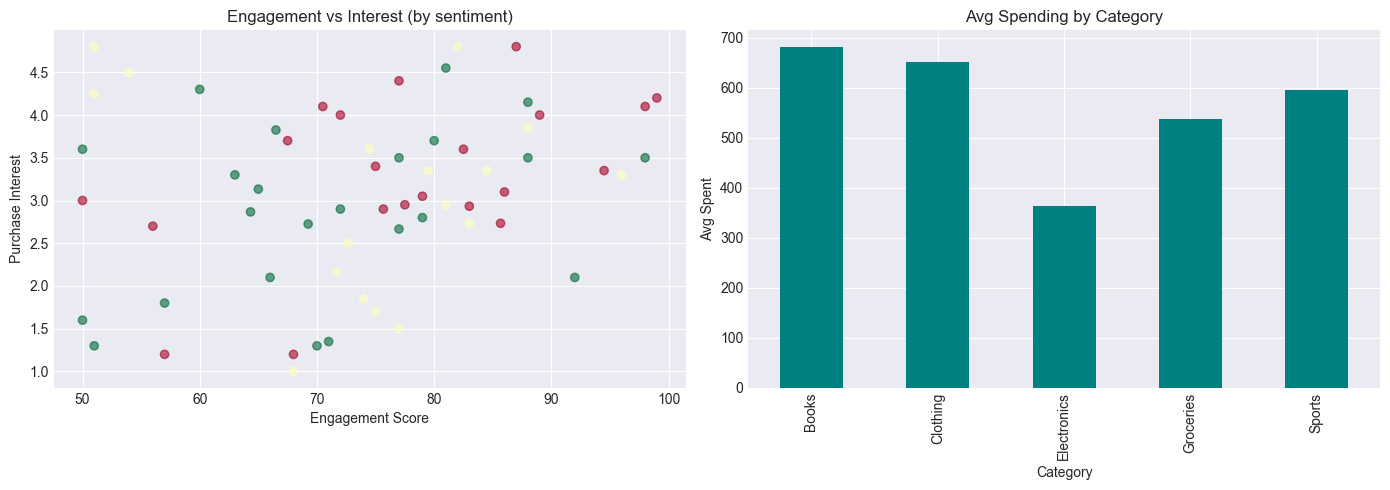

In [55]:
# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(merged_df['avg_engagement_score'], merged_df['avg_purchase_interest'], 
                c=merged_df['sentiment_encoded'], cmap='RdYlGn', alpha=0.6)
axes[0].set_xlabel('Engagement Score')
axes[0].set_ylabel('Purchase Interest')
axes[0].set_title('Engagement vs Interest (by sentiment)')
merged_df.groupby('most_purchased_category')['total_spent'].mean().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Avg Spending by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Spent')
plt.tight_layout()
plt.show()

## 10. SAVE DATASET

In [56]:
merged_df.to_csv('merged_customer_data.csv', index=False)
print(" Saved: merged_customer_data.csv")
print(f" Shape: {merged_df.shape}")
print(" Ready for product recommendation model!")

 Saved: merged_customer_data.csv
 Shape: (61, 23)
 Ready for product recommendation model!


In [57]:
# ============================================
# Model Training & Evaluation
# ============================================

print("="*50)
print("PRODUCT RECOMMENDATION MODEL")
print("="*50)

# Prepare features and target
feature_cols = ['avg_purchase_amount', 'total_spent', 'transaction_count', 
                'avg_rating', 'avg_engagement_score', 'avg_purchase_interest',
                'engagement_x_interest', 'spending_per_transaction', 'sentiment_encoded'] + \
                [col for col in merged_df.columns if col.startswith('platform_')]

X = merged_df[feature_cols]
y = merged_df['most_purchased_category']

print(f"\n Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f" Target classes: {y.unique().tolist()}")
print(f"\nClass distribution:\n{y.value_counts()}")


PRODUCT RECOMMENDATION MODEL

 Features: 29, Samples: 61
 Target classes: ['Books', 'Electronics', 'Sports', 'Clothing', 'Groceries']

Class distribution:
most_purchased_category
Electronics    18
Books          14
Clothing       14
Sports          8
Groceries       7
Name: count, dtype: int64


In [58]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Train set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")


 Train set: 48 samples
 Test set: 13 samples


In [59]:
# Train model
print("\n Training Random Forest...")
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n Accuracy: {accuracy:.3f}")
print(f" F1-Score (weighted): {f1:.3f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred))


 Training Random Forest...

 Accuracy: 0.385
 F1-Score (weighted): 0.354

 Classification Report:
              precision    recall  f1-score   support

       Books       0.14      0.33      0.20         3
    Clothing       0.00      0.00      0.00         3
 Electronics       1.00      1.00      1.00         4
   Groceries       0.00      0.00      0.00         1
      Sports       0.00      0.00      0.00         2

    accuracy                           0.38        13
   macro avg       0.23      0.27      0.24        13
weighted avg       0.34      0.38      0.35        13



c:\Users\Kumi Yunis\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kumi Yunis\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kumi Yunis\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


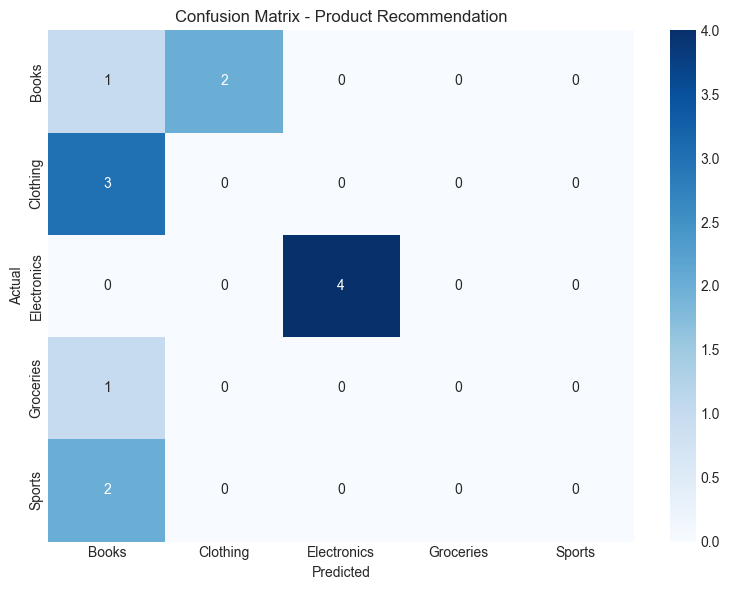

C:\Users\Kumi Yunis\AppData\Local\Temp\ipykernel_15616\1361040244.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')


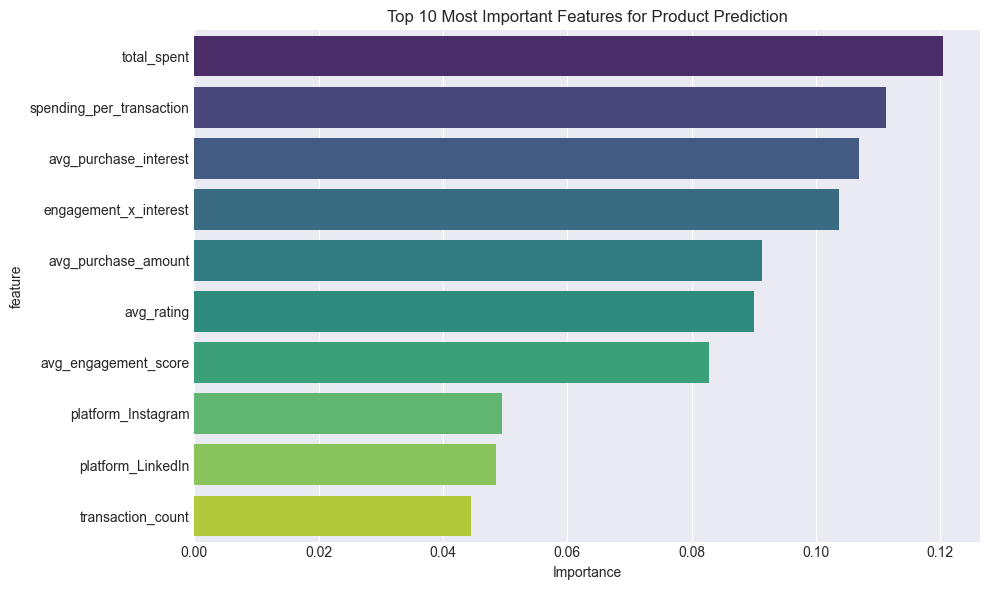


 Top 5 Most Important Features:
                 feature  importance
             total_spent    0.120378
spending_per_transaction    0.111273
   avg_purchase_interest    0.106947
   engagement_x_interest    0.103677
     avg_purchase_amount    0.091271


In [61]:
# ============================================
# Visualizations 
# ============================================

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.title('Confusion Matrix - Product Recommendation')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature Importance
# Build feature importance from the exact columns used by the trained model
feature_importance = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    })
    .groupby('feature', as_index=False)['importance']  # merge duplicate column names if present
    .sum()
    .sort_values('importance', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Most Important Features for Product Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\n Top 5 Most Important Features:")
print(feature_importance.head(5).to_string(index=False))



